# Case Bank Personal Loan
> https://www.kaggle.com/datasets/krantiswalke/bank-personal-loan-modelling 

     Autora do Notebook: Isabella Heder 

Este case trata de um banco (Thera Bank) cujo objetivo é explorar formas de converter clientes de passivos (liability customers) em clientes de empréstimos pessoais, mantendo-os também como depositantes.

Uma campanha realizada no ano passado com esses clientes apresentou uma taxa de conversão superior a 9%, considerada bastante positiva.
Esse resultado motivou o departamento de marketing a desenvolver novas campanhas com segmentação mais inteligente (target marketing), buscando:

- Aumentar a taxa de conversão
- Reduzir custos de campanha
- Maximizar o retorno sobre o investimento (ROI)

### Objetivo do Projeto
O objetivo é construir um modelo de classificação capaz de:
- Prever a probabilidade de um cliente aceitar uma oferta de empréstimo pessoal.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score

import kagglehub
from kagglehub import KaggleDatasetAdapter

In [4]:
file_path = "Bank_Personal_Loan_Modelling.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "krantiswalke/bank-personal-loan-modelling", file_path)

Dicionário de dados:

| Coluna | Significado |
|--------|-------------|
| ID | ID do cliente |
| Age | idade do cliente |
| Experience | anos de experiência profissional |
|Income | Income anual do cliente ($000) |
| ZIP Code | CEP do cliente |
| Family | tamanho da família do cliente |
| CCAvg | média gasta no cartão de crédito por mês ($000) |
| Education | Nível de educação (1: graduação, 2: pós-graduação, 3: avançado/professional) |
| Mortgage | valor do financiamento imobiliário (se tiver) |
| Personal Loan | TARGET - 0: Não aceitou o empréstimo; 1: Aceitou o empréstimo |
| Securities Account | cliente possui conta de investimentos no banco (0: não, 1: sim) |
| CD Account | cliente possui um Certificado de Depósito (CD) (0: não, 1: sim) |
| Online | cliente utiliza internet banking (0: não, 1: sim) |
| Credit card | cliente possui cartão de crédito do banco (0: não, 1: sim) |

In [5]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [7]:
df.duplicated().sum()

np.int64(0)

- Sem dados nulos
- Sem duplicados
- Todas as colunas são numéricas (sem variáveis categóricas)

In [8]:
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


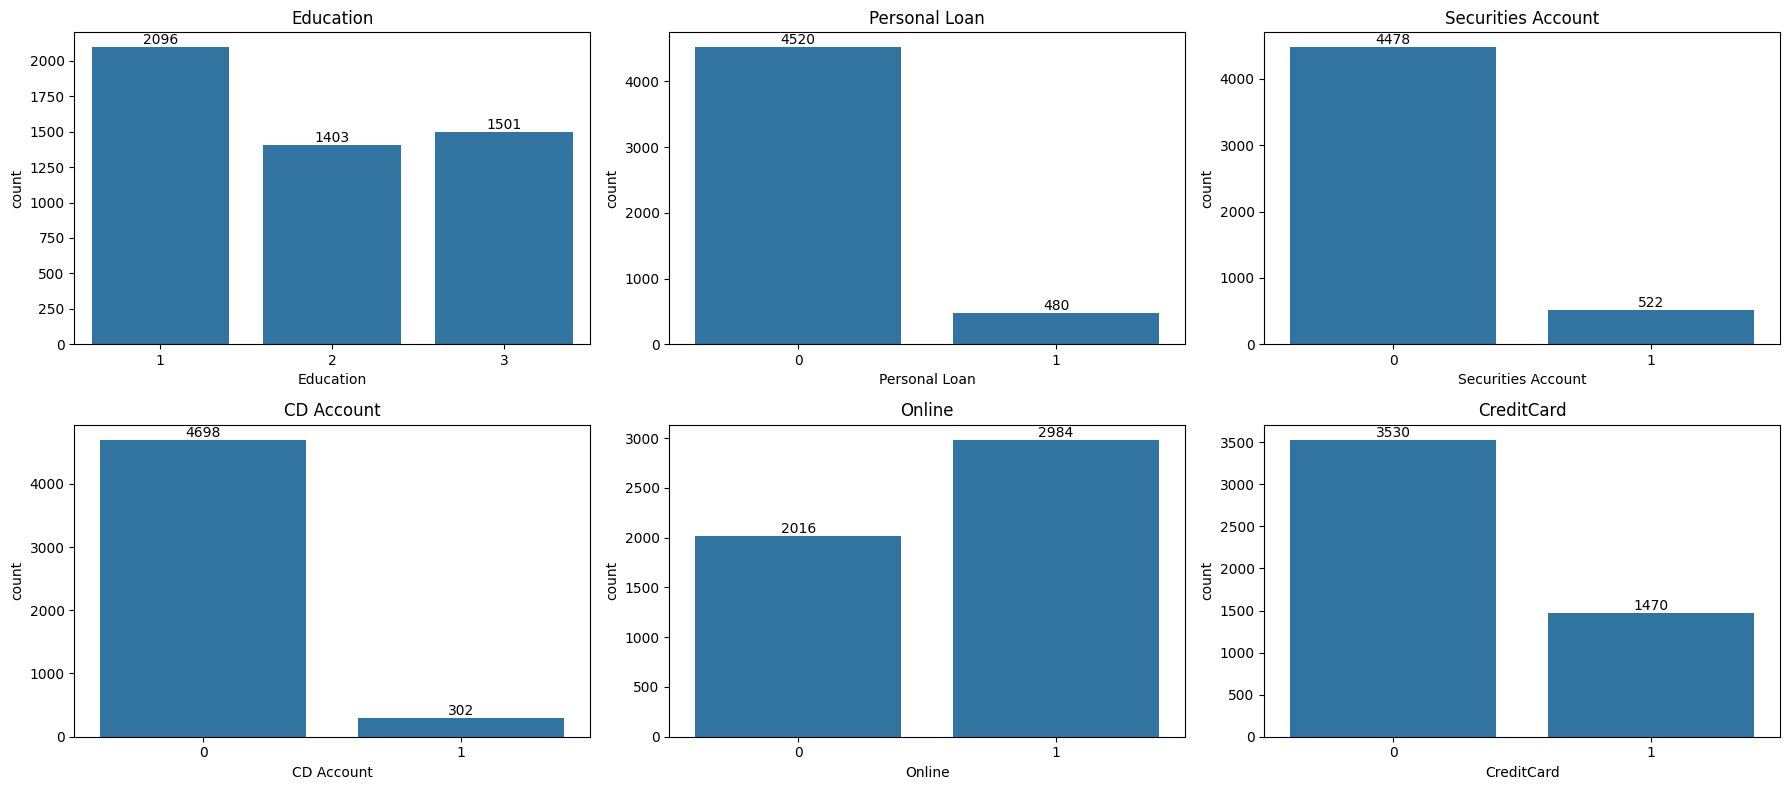

In [9]:
variaveis_discretas  = ['Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']

plt.figure(figsize=(18, 8))
for i, col in enumerate(variaveis_discretas):
    ax = plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df, ax=ax)
    plt.title(col)
    
    # adiciona os valores nas barras
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

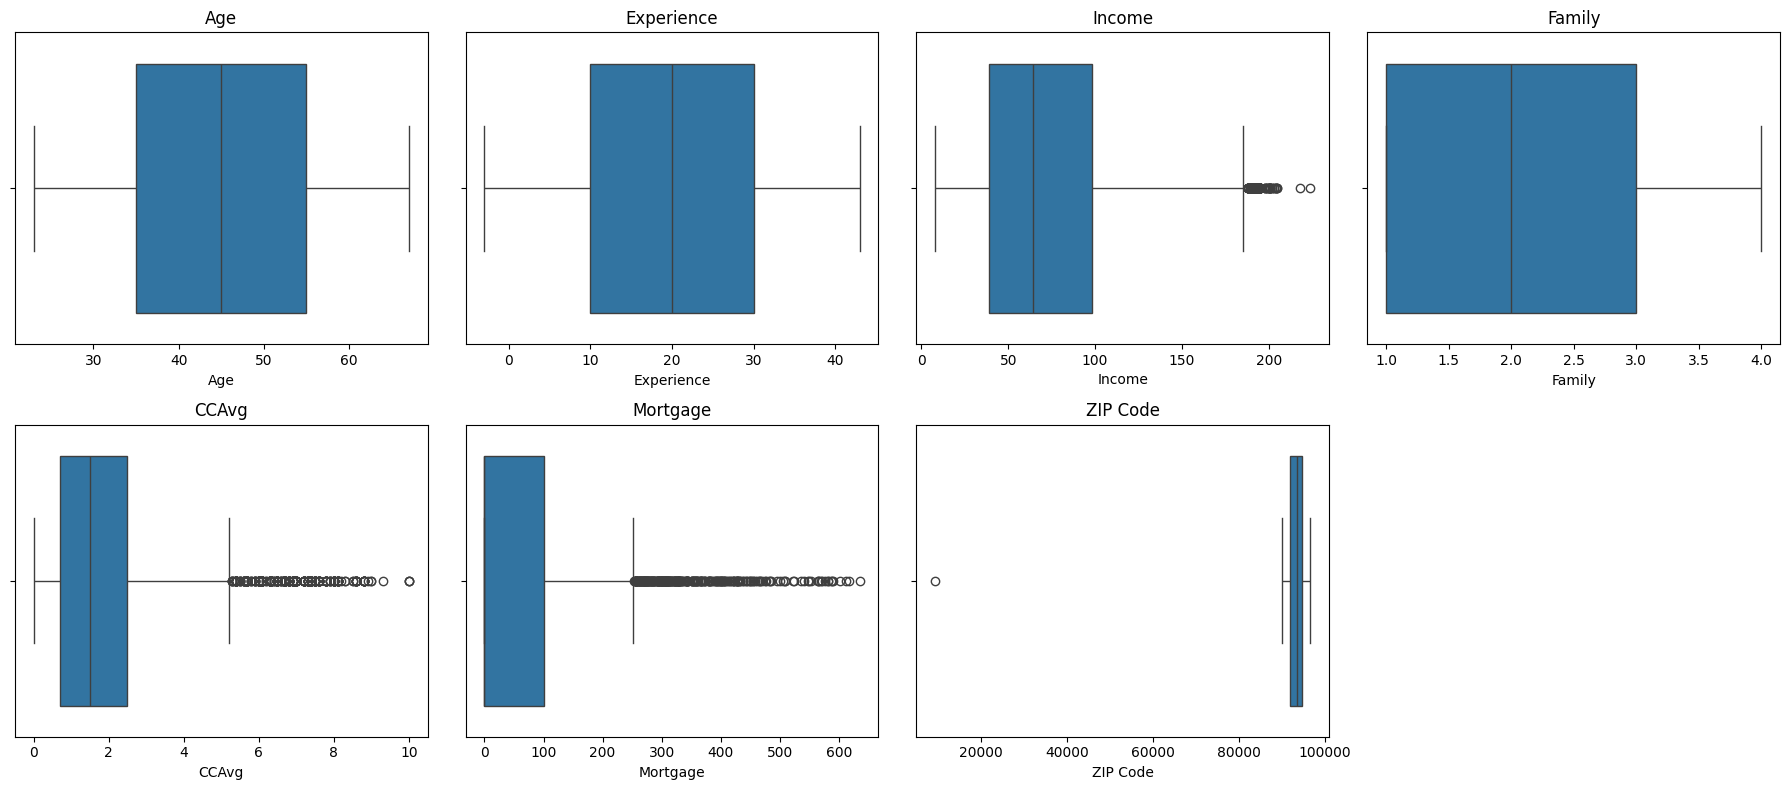

In [10]:
variaveis_continuas = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage', 'ZIP Code']
plt.figure(figsize=(18, 8))

for i, col in enumerate(variaveis_continuas):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(x=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

#### Interpretação:
- Experience conta com valores negativos (necessidade de correção)
- Income conta com alguns outliers
- CCAvg possui cauda longa com vários outliers acima de ~5
- Mortgage possui cauda longa com muitos outliers (até ~600+)

     Experience 
Presença de valores negativos, o que com certeza indica inconsistência nos dados

Para tratar essa questão:
- Ao invés de utilizar abs(), e introduzir erro artificial
- Eu decidi remover os dados inconsistentes, focando na qualidade dos dados, sem inventar 

In [ ]:
print(len(df[df['Experience'] < 0]))
print(df['Experience'].min())

df = df[df['Experience'] >= 0]

52
-3


     Tratamento de Outliers 
Eu só vou tratar os outliers se eles atrapalharem o desempenho do modelo

Por isso, eu vou criar um df novo, com os outliers tratados e posteriormente eu vejo se isso ajudou ou não o modelo

In [12]:
df[['Income', 'CCAvg', 'Mortgage']].skew()

Income      0.842004
CCAvg       1.594624
Mortgage    2.104585
dtype: float64

In [13]:
df_outliers = df.copy()

#df_outliers['Income'] = np.log1p(df['Income'])
df_outliers['CCAvg'] = np.log1p(df['CCAvg'])
df_outliers['Mortgage'] = np.log1p(df['Mortgage'])

### Correlação entre variáveis

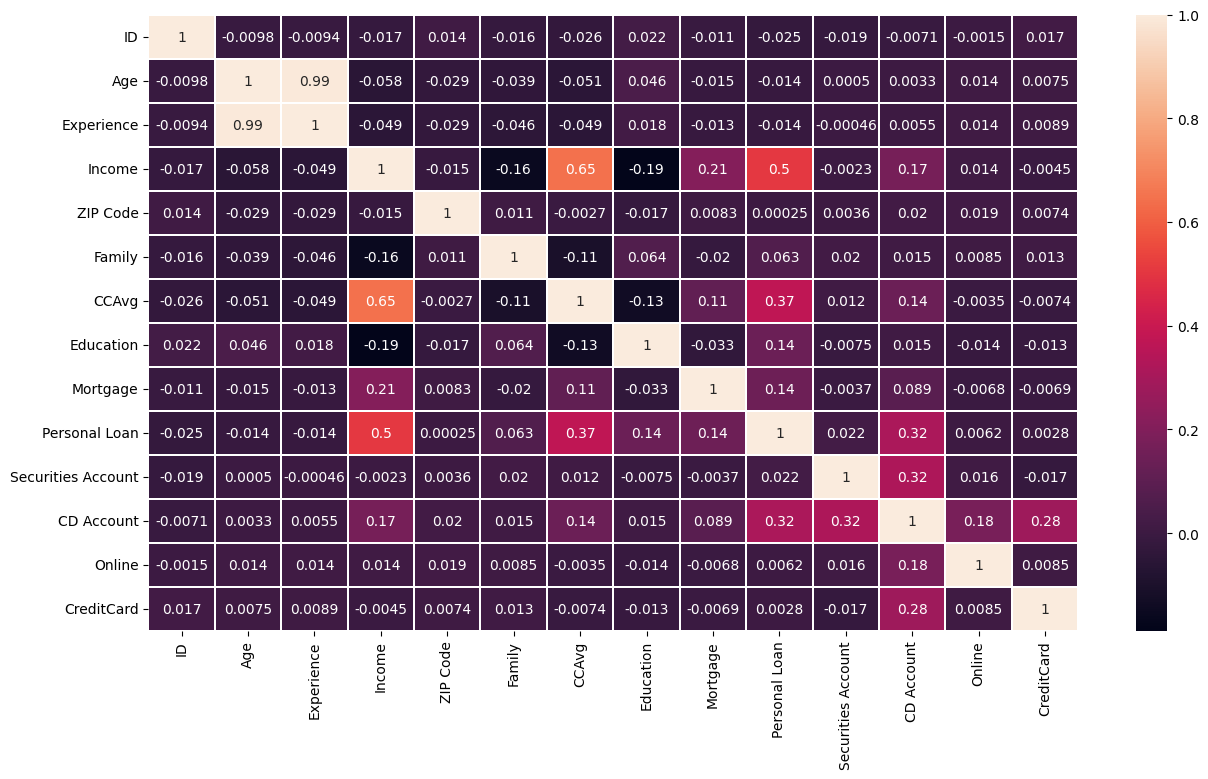

In [14]:
matriz_correlacao = df.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(matriz_correlacao, 
            annot = True, 
            linewidths = 0.2)
plt.show()

Interpretação:
- A variável target (``Personal Loan``), tem correlação com ``Income``, ``CCAvg``, ``CD Account`` (``Education`` e ``Mortgage`` também pode se considerar)
- Age e Experience não apresentam correlação significativa com nenhuma variável, além de apresentarem multicolinearidade entre elas (0.99)
- ZIP Code não apresenta correlação significativa com nenhuma variável (retirar)
- CCAvg e Income apresentam uma correlação de +0.65 (significativa!) --> quanto maior o income maior **tende** a ser o CCAvg

In [15]:
df = df.drop(columns=['Experience']) # retirando por multicolinearidade
df = df.drop(columns=['ZIP Code']) # retirando por não ser relevante para o modelo

#### BoxPlot Personal Loan vs Income 

<Axes: xlabel='Personal Loan', ylabel='Income'>

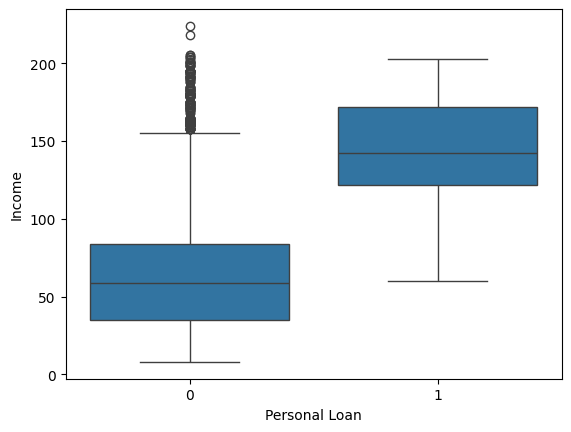

In [16]:
sns.boxplot(x='Personal Loan', y='Income', data=df)

**Interpretação**:
- Aceitaram --> mediana (Income) = ~140
- Não aceitaram --> mediana (Income) = ~60

> Clientes com renda maior têm mais chance de aceitar o empréstimo

Porém:
- Existem clientes com Income alto que não aceitam
- e alguns com renda média que aceitam

#### BoxPlot Personal Loan vs CCAvg 

<Axes: xlabel='Personal Loan', ylabel='CCAvg'>

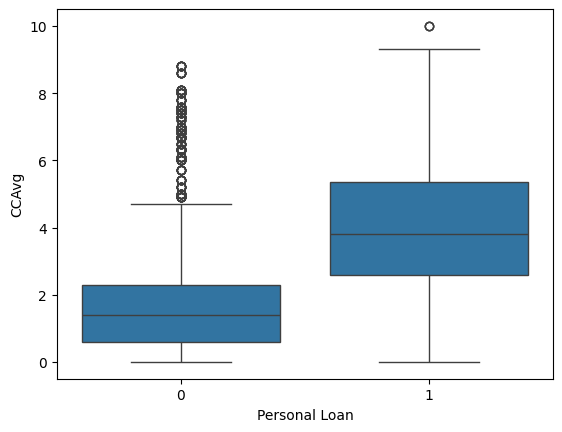

In [17]:
sns.boxplot(x='Personal Loan', y='CCAvg', data=df)

**Interpretação:**
- Aceitaram --> mediana (CCAvg) = ~3.8
- Não aceitaram --> mediana (CCAvg) = ~1.9

> Clientes que gastam mais no cartão de crédito tem mais chance de aceitar empréstimo

#### Scatterplot Income vs CCAvg (+ Personal Loan)

<Axes: xlabel='Income', ylabel='CCAvg'>

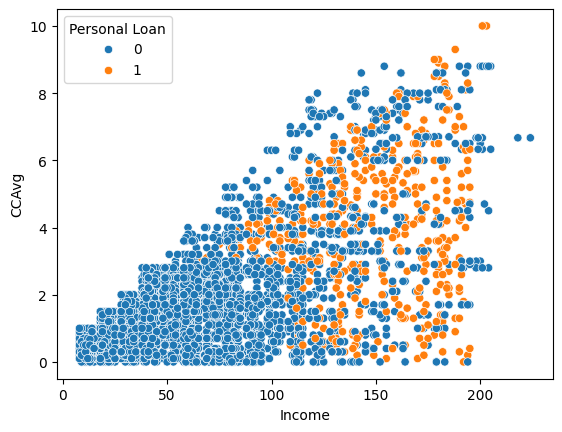

In [18]:
sns.scatterplot(
    x='Income',
    y='CCAvg',
    hue='Personal Loan',
    data=df
)

Interpretação:
- Os pontos laranjas (1) se concentram em Income > ~100 e CCAvg > ~2
- Essa é a zona onde a probabilidade de aceitar empréstimo é maior
- Existe uma zona onde a probabilidade é bem menor
_____________________

## Feature Engineering

Ideia:
- Criação de 2 features:
    - Income x CCAvg = interação entre as duas (multiplicando)
    - Zona de alta probabilidade = Income > 100 e CCAvg > 2.5

> O **foco do modelo** é ter a **maior quantidade de True Positives** (1:1) = captura mais clientes reais (melhor recall)

Testes:
| Features | modelo | TP | TN | threshold |
|----------|--------|----|----|-----------|
| income_ccavg | 1 | 78 | 831 | 0.6 |
| income_ccavg | 2 | 77 | 837 |0.6 |
| income_ccavg + zona_prob_alta | 1 | **79** | 832 |0.6 |
| income_ccavg + zona_prob_alta | 2 | 78 | 835 |0.6 |
| zona_prob_alta | 1 | 73 | 840 | 0.6 | 
| zona_prob_alta | 2 | 76 | 839 | 0.6 |
| -- | 1 | 75 | 843 |0.6 |
| -- | 2 | 76 | 839 |0.6 |

     1: Feature de interação entre Income e CCAvg, que são as variáveis mais correlacionadas com Personal Loan 

In [19]:
df['income_ccavg'] = df['Income'] * df['CCAvg']

     2: Feature de zona de alta probabilidade de aceitar o empréstimo, identificada pela análise exploratória 

In [20]:
df['zona_prob_alta'] = ((df['Income'] > 100) & (df['CCAvg'] > 2.5)).astype(int)

______________________
## Criação dos modelos

Serão **``2 modelos``**:
- 1o: Outliers não tratados (Income e CCAvg originais)
- 2o: Outliers tratados (Income e CCAvg com log1p)

> O **foco do modelo** é ter a **maior quantidade de True Positives** (1:1) = captura mais clientes reais (melhor recall)

#### Modelo 1
Outliers não tratados (Income e CCAvg originais)

In [21]:
X = df.drop(columns=['Personal Loan'])
y = df['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
model = LogisticRegression(max_iter=10000, class_weight='balanced')
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

# threshold de 0.6 para melhorar precisão e balanear melhor as classes
y_pred = (y_prob > 0.6).astype(int) 

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.92      0.95       903
           1       0.53      0.91      0.67        87

    accuracy                           0.92       990
   macro avg       0.76      0.91      0.81       990
weighted avg       0.95      0.92      0.93       990



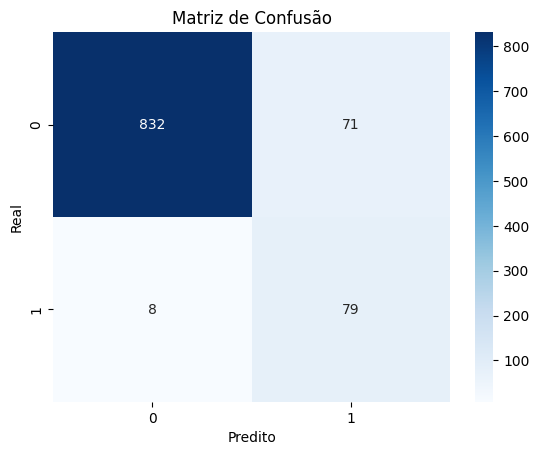

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

#### Modelo 2
Outliers tratados (Income e CCAvg com log1p)

In [24]:
# feature engineering
df_outliers['income_ccavg'] = df_outliers['Income'] * df_outliers['CCAvg']
df_outliers['zona_prob_alta'] = ((df_outliers['Income'] > 100) & (df_outliers['CCAvg'] > 2.5)).astype(int)

In [25]:
df_outliers = df_outliers.drop(columns=['Experience']) # retirando por multicolinearidade
df_outliers = df_outliers.drop(columns=['ZIP Code']) # retirando por não ser relevante para o modelo

In [26]:
X_2 = df_outliers.drop(columns=['Personal Loan'])
y_2 = df_outliers['Personal Loan']

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

In [27]:
model_2 = LogisticRegression(max_iter=10000, class_weight='balanced')
model_2.fit(X_train_2, y_train_2)

y_prob_2 = model_2.predict_proba(X_test_2)[:, 1]

# threshold de 0.6 para melhorar precisão e balanear melhor as classes
y_pred_2 = (y_prob_2 > 0.6).astype(int)

print(classification_report(y_test_2, y_pred_2))

              precision    recall  f1-score   support

           0       0.99      0.92      0.96       903
           1       0.53      0.90      0.67        87

    accuracy                           0.92       990
   macro avg       0.76      0.91      0.81       990
weighted avg       0.95      0.92      0.93       990



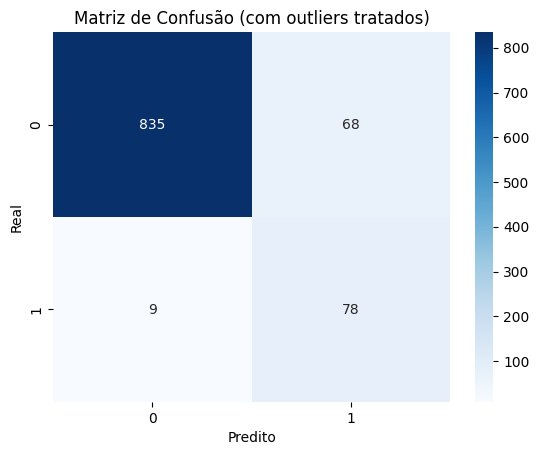

In [28]:
cm = confusion_matrix(y_test_2, y_pred_2)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão (com outliers tratados)")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

## Escolha do Modelo Final

Conforme eu expliquei anteriormente, o foco deste case é ter a maior quantidade de True Positives (1:1) possível, porque isso significa que o modelo está identificando corretamente os clientes que aceitarão o empréstimo, o que é crucial para a estratégia de marketing do banco. A precisão (precision) é importante, mas a prioridade é garantir que não estamos perdendo oportunidades de identificar clientes potenciais (maximizando os True Positives), mesmo que isso signifique aceitar um número maior de False Positives.

> Por isso, **o modelo escolhido foi o PRIMEIRO MODELO, com 79 True Positives**

In [29]:
print('Acurácia:', accuracy_score(y_test, y_pred))
print('Precisão:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))

Acurácia: 0.9202020202020202
Precisão: 0.5266666666666666
Recall: 0.9080459770114943
